In [2]:
import sys
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import (
    DATA_DIR,
    IMAGE_DIR,
    METADATA_PATH,
    GROUND_TRUTH_PATH,
)

np.set_printoptions(precision=1, suppress=True)

print("Project root:", PROJECT_ROOT)
print("Image directory:", IMAGE_DIR)

Project root: c:\Users\Kinjal Chatterjee\Desktop\MILK10K-Project
Image directory: C:\Users\Kinjal Chatterjee\Downloads\MILK10k\images


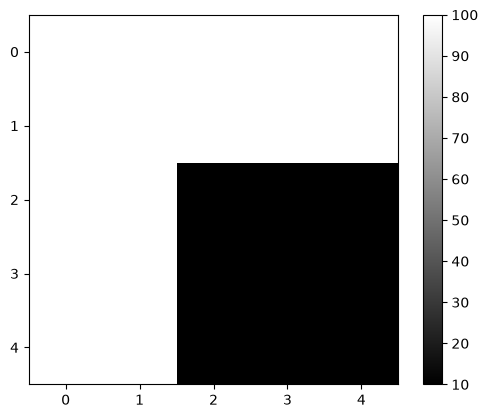

[[100 100 100 100 100]
 [100 100 100 100 100]
 [100 100  10  10  10]
 [100 100  10  10  10]
 [100 100  10  10  10]]


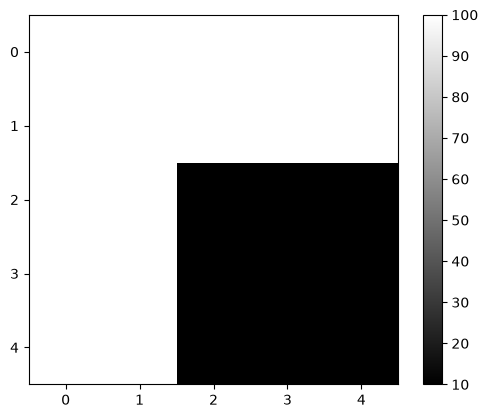

In [3]:
img = np.array([
    [100, 100, 100, 100, 100],
    [100, 100, 100, 100, 100],
    [100, 100,  10,  10,  10],
    [100, 100,  10,  10,  10],
    [100, 100,  10,  10,  10]
])

plt.imshow(img, cmap="gray")
plt.colorbar()
plt.show()


print(img)

plt.imshow(img, cmap="gray")
plt.colorbar()
plt.show()



In [4]:
kernel=np.ones((3,3))/9
print("Sum of weights of the box blur kernel: ", kernel.sum())


Sum of weights of the box blur kernel:  1.0


In [5]:
row, col= 1,1
patch= img[row:row+3, col:col+3]
products= patch*kernel
total=products.sum()
print(patch)
print(products)
print(total)


[[100 100 100]
 [100  10  10]
 [100  10  10]]
[[11.1 11.1 11.1]
 [11.1  1.1  1.1]
 [11.1  1.1  1.1]]
60.0


In [6]:
def conv_step(img, kernel, row, col):
   """ "one window: patch -> products -> sum"""
   k= kernel.shape[0]
   patch=img[row:row+k, col:col+k]
   products=patch*kernel
   return patch, products, products.sum()


#position of the window(0,0)
conv_step(img, kernel, 0, 0)


(array([[100, 100, 100],
        [100, 100, 100],
        [100, 100,  10]]),
 array([[11.1, 11.1, 11.1],
        [11.1, 11.1, 11.1],
        [11.1, 11.1,  1.1]]),
 np.float64(90.0))

In [7]:
#Sliding the Kernel
n_out= img.shape[0] - kernel.shape[0]+1
out= np.zeros((n_out, n_out))

for r in range(n_out):
    for c in range(n_out):
        patch, products, total = conv_step(img, kernel, r, c)
        out[r, c] = total
        print(f"Window at position {r}, {c} -> {total}")



Window at position 0, 0 -> 90.0
Window at position 0, 1 -> 80.0
Window at position 0, 2 -> 70.0
Window at position 1, 0 -> 80.0
Window at position 1, 1 -> 60.0
Window at position 1, 2 -> 40.0
Window at position 2, 0 -> 70.0
Window at position 2, 1 -> 40.0
Window at position 2, 2 -> 10.0


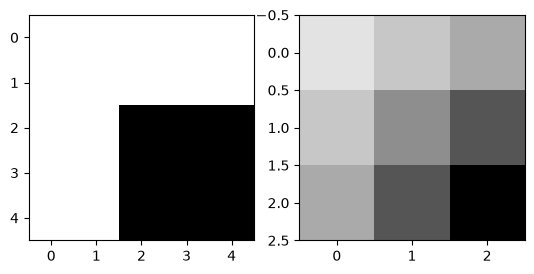

In [8]:
plt.subplot(1,2,1)
plt.imshow(img, 'gray', vmin=10, vmax=100)
plt.subplot(1,2,2)
plt.imshow(out, cmap='gray', vmin=10, vmax=100)


In [9]:
def output_size(n, k, padding=0, stride=1):
    return(n+2*padding-k) // stride+1

#Input 5x5, k 3x3, padding 0, stride 2
print(output_size(5,3,0,2))


2


In [10]:
def conv2d(img, kernel, padding=0, stride=1, pad_mode="constant"):
    k = kernel.shape[0]


    if padding > 0:
        img = np.pad(img, padding, mode=pad_mode)

  
    n_out = output_size(img.shape[0], k, padding=0, stride=stride)
    out = np.zeros((n_out, n_out))

   
    for r in range(n_out):
        for c in range(n_out):
            _, _, total = conv_step(img, kernel, r * stride, c * stride)
            out[r, c] = total

    return out

conv2d(img, kernel, padding=0, stride=2)

array([[90., 70.],
       [70., 10.]])

In [11]:
import numpy as np

KERNELS = {
    "identity": np.array([[0, 0, 0],
                          [0, 1, 0],
                          [0, 0, 0]]),

    "box_blur": np.ones((3, 3)) / 9,

    "gaussian": np.array([[1, 2, 1],
                          [2, 4, 2],
                          [1, 2, 1]]) / 16,

    "sharpen": np.array([[ 0, -1,  0],
                         [-1,  5, -1],
                         [ 0, -1,  0]]),

    "outline": np.array([[-1, -1, -1],
                         [-1,  8, -1],
                         [-1, -1, -1]]),

    "emboss": np.array([[-2, -1, 0],
                        [-1,  1, 1],
                        [ 0,  1, 2]]),

    "sobel_x": np.array([[-1, 0, 1],
                         [-2, 0, 2],
                         [-1, 0, 1]]),

    "sobel_y": np.array([[-1, -2, -1],
                         [ 0,  0,  0],
                         [ 1,  2,  1]]),
}

(450, 600)


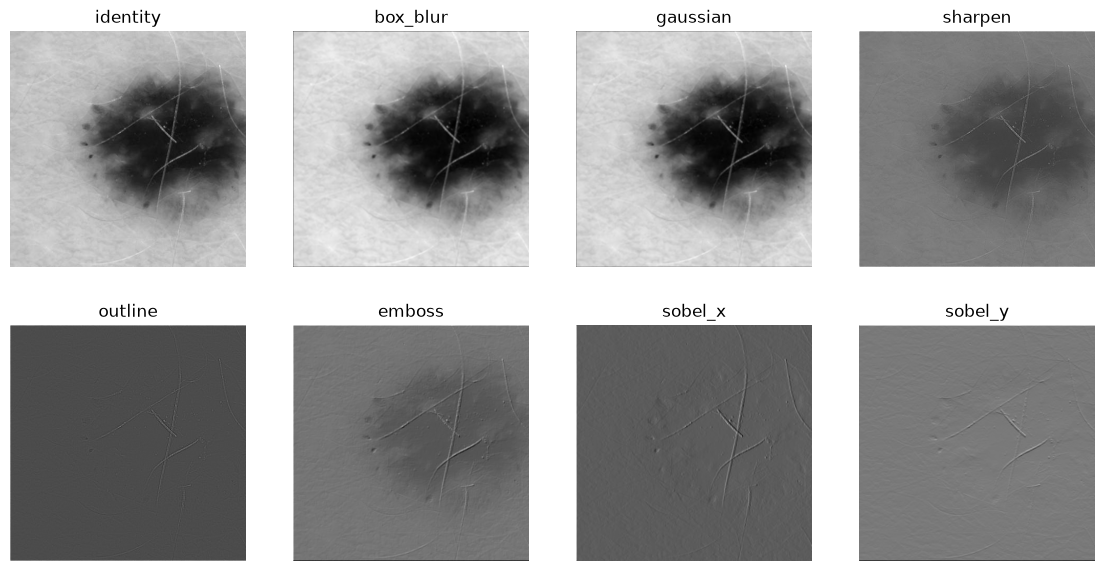

In [13]:
from PIL import Image

image_path = IMAGE_DIR / "ISIC_0073863.jpg"

img = np.array(Image.open(image_path).convert("L"), dtype=float)

print(img.shape)   # (H, W)

fig, axes = plt.subplots(2, 4, figsize=(14, 7))
for ax, (name, kern) in zip(axes.ravel(), KERNELS.items()):
    result = conv2d(img, kern, padding=1, stride=1)
    ax.imshow(result, cmap="gray")
    ax.set_title(name)
    ax.axis("off")
plt.show()

In [14]:
def fast_conv2d(img, kernel):
    from scipy import ndimage

    """Same as conv2d(..., padding=1, pad_mode="symmetric") but in optimized C."""
    return ndimage.correlate(img, kernel, mode="reflect")


t0 = time.perf_counter()

slow = conv2d(
    img,
    KERNELS["box_blur"],
    padding=1,
    pad_mode="symmetric"
)

t_slow = time.perf_counter() - t0


t0 = time.perf_counter()

fast = fast_conv2d(
    img,
    KERNELS["box_blur"]
)

t_fast = time.perf_counter() - t0


print(
    f"loops {t_slow:.3f}s | "
    f"scipy {t_fast:.4f}s | "
    f"{t_slow / t_fast:.0f}x faster"
)

print("same result:", np.allclose(slow, fast))

loops 0.381s | scipy 0.0028s | 134x faster


ValueError: operands could not be broadcast together with shapes (450,450) (450,600) 